# Noise Realism Showcase in `invertmeeg`

This notebook demonstrates the new simulation noise controls and visual diagnostics:

- spatial covariance modes (`None`, `diagonal`, `banded`, `cholesky`, `low_rank`)
- temporal noise coloring (`noise_temporal_beta`)
- rank deficiency via projectors (`noise_rank_deficiency`)
- true vs estimated noise covariance (`noise_cov_true`, `noise_cov_est`)

The goal is to inspect solver-relevant conditions beyond clean-room white-noise simulations.


In [10]:
# %matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import matplotlib.pyplot as plt
import numpy as np

from invert.forward import create_forward_model, get_info
from invert.simulate import SimulationConfig, SimulationGenerator

## 1. Build a compact forward model

We keep the source space small (`ico2`) so visualizations run fast in a notebook.


In [12]:
info = get_info(kind="biosemi32")
fwd = create_forward_model(sampling="ico2", info=info)

n_chans, n_dipoles = fwd["sol"]["data"].shape
print(f"Channels: {n_chans}, Dipoles: {n_dipoles}")

Channels: 32, Dipoles: 324


## 2. Helper to generate one deterministic sample per setting

In [13]:
def generate_one(
    *,
    mode=None,
    noise_color_coeff=0.65,
    noise_temporal_beta=0.0,
    noise_rank_deficiency=0,
    seed=7,
):
    config = SimulationConfig(
        batch_size=1,
        batch_repetitions=1,
        n_sources=(2, 3),
        n_orders=(0, 2),
        n_timepoints=120,
        snr_range=(0.0, 0.0),
        simulation_mode="patches",
        correlation_mode=mode,
        noise_color_coeff=noise_color_coeff,
        noise_temporal_beta=noise_temporal_beta,
        noise_rank_deficiency=noise_rank_deficiency,
        apply_sensor_projector=True,
        return_noise_cov=True,
        estimate_noise_cov=True,
        noise_cov_n_baseline=256,
        noise_cov_shrinkage=0.05,
        random_seed=seed,
    )
    gen = SimulationGenerator(fwd, config=config)
    x, y, meta = next(gen.generate())
    row = meta.iloc[0]
    return {
        "x": x[0],
        "y": y[0],
        "meta": row,
    }

## 3. Compare spatial covariance modes

Each row uses the same source process and SNR target, but a different spatial noise model.


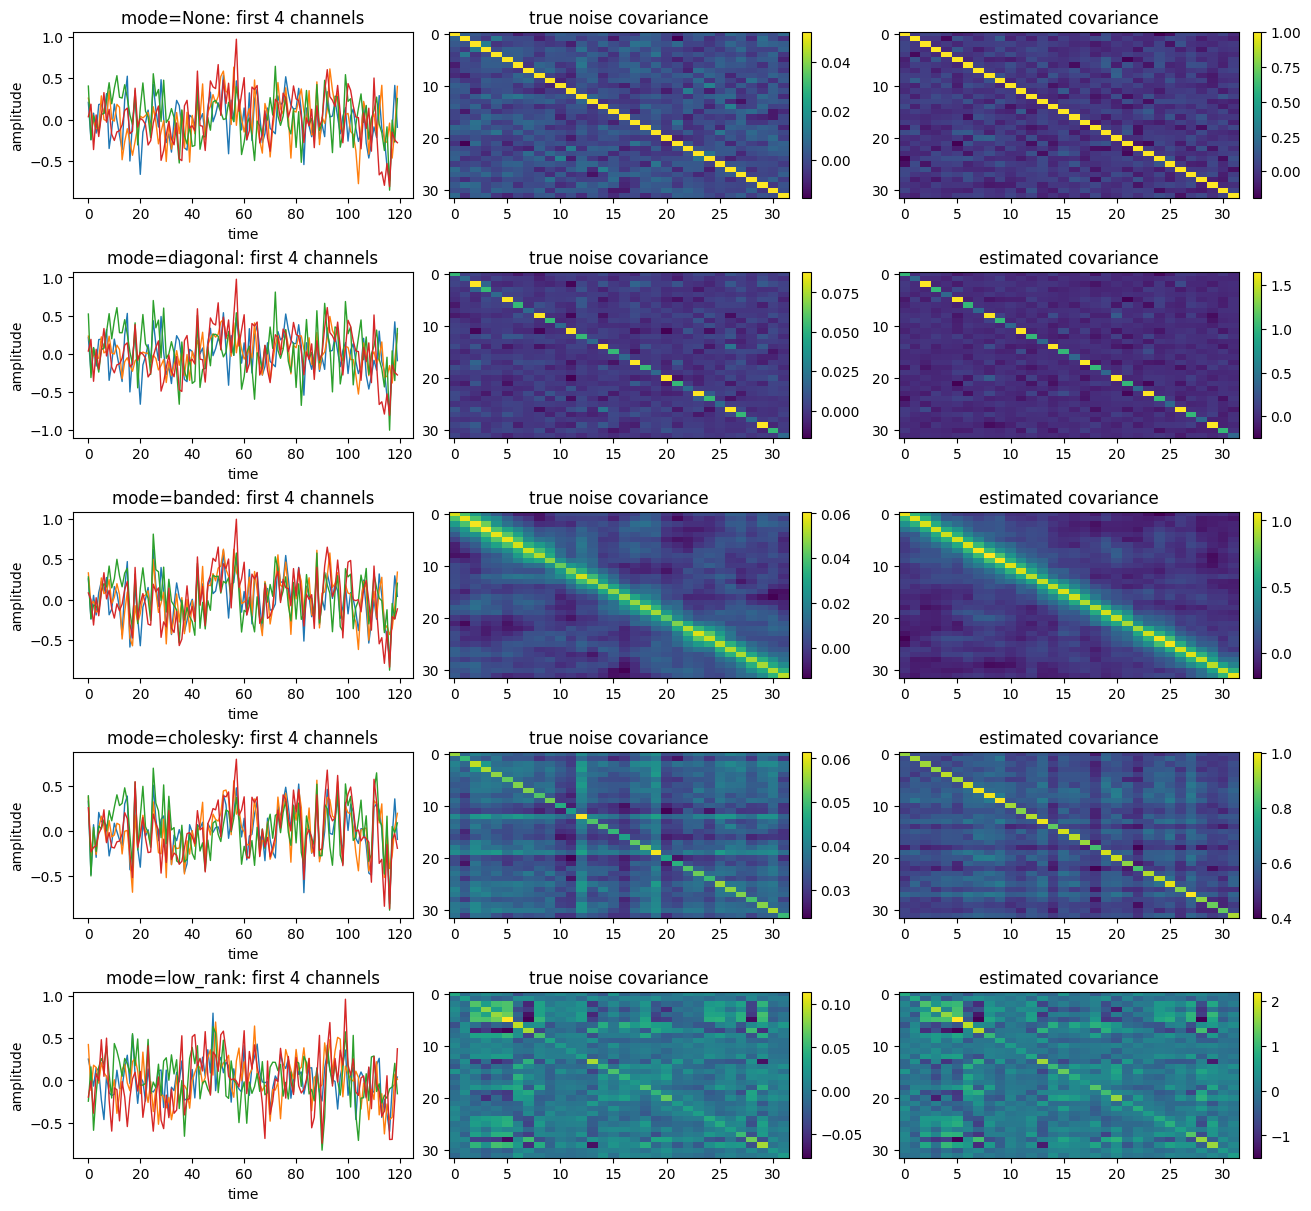

In [14]:
modes = [None, "diagonal", "banded", "cholesky", "low_rank"]
mode_results = {
    str(mode): generate_one(mode=mode, noise_color_coeff=0.65, noise_temporal_beta=0.0, seed=11)
    for mode in modes
}

fig, axes = plt.subplots(len(modes), 3, figsize=(13, 2.4 * len(modes)), constrained_layout=True)

for i, mode in enumerate(modes):
    key = str(mode)
    res = mode_results[key]
    x = res["x"]
    m = res["meta"]

    # Sensor time series preview
    axes[i, 0].plot(x[:4].T, lw=1.0)
    axes[i, 0].set_title(f"mode={mode}: first 4 channels")
    axes[i, 0].set_xlabel("time")
    axes[i, 0].set_ylabel("amplitude")

    # True covariance
    c_true = m["noise_cov_true"]
    im1 = axes[i, 1].imshow(c_true, cmap="viridis", aspect="auto")
    axes[i, 1].set_title("true noise covariance")
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # Estimated covariance
    c_est = m["noise_cov_est"]
    im2 = axes[i, 2].imshow(c_est, cmap="viridis", aspect="auto")
    axes[i, 2].set_title("estimated covariance")
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.show()

## 4. Eigenspectrum view (true vs estimated covariance)

This makes rank and conditioning differences easy to inspect.


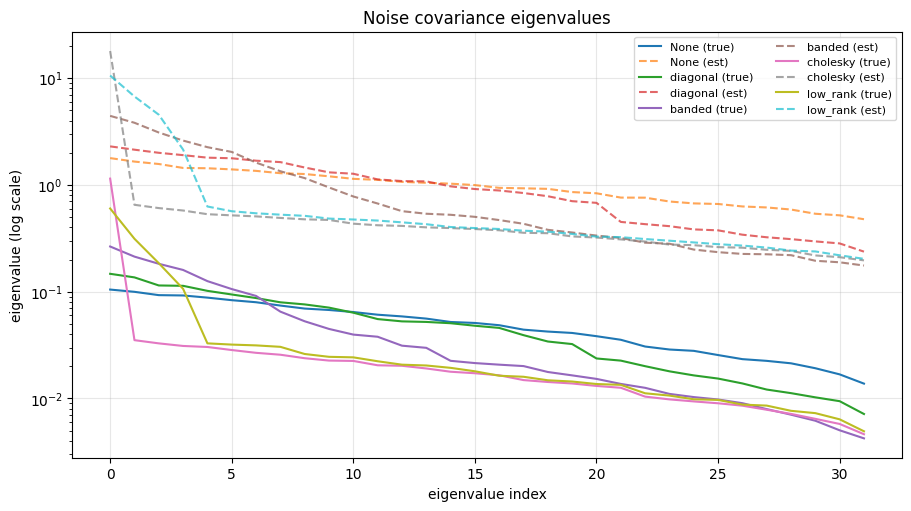

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5), constrained_layout=True)

for mode in modes:
    key = str(mode)
    m = mode_results[key]["meta"]
    evals_true = np.sort(np.linalg.eigvalsh(m["noise_cov_true"]))[::-1]
    evals_est = np.sort(np.linalg.eigvalsh(m["noise_cov_est"]))[::-1]

    ax.semilogy(evals_true, label=f"{mode} (true)")
    ax.semilogy(evals_est, "--", alpha=0.7, label=f"{mode} (est)")

ax.set_title("Noise covariance eigenvalues")
ax.set_xlabel("eigenvalue index")
ax.set_ylabel("eigenvalue (log scale)")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()

## 5. Rank deficiency via projectors

We increase `noise_rank_deficiency` and inspect projector/covariance ranks.


In [16]:
rank_settings = [0, 2, 4, 6]
rows = []

for rloss in rank_settings:
    out = generate_one(
        mode="banded",
        noise_color_coeff=0.6,
        noise_temporal_beta=0.0,
        noise_rank_deficiency=rloss,
        seed=20 + rloss,
    )
    m = out["meta"]
    rows.append((
        rloss,
        int(m["projector_rank"]),
        int(m["noise_cov_rank_true"]),
        int(m["noise_cov_rank_est"]),
        float(m["snr"]),
        float(m["snr_realized"]),
    ))

print("rank_def | projector_rank | cov_rank_true | cov_rank_est | snr_target | snr_realized")
for row in rows:
    print(f"{row[0]:8d} | {row[1]:14d} | {row[2]:13d} | {row[3]:12d} | {row[4]:10.3f} | {row[5]:12.3f}")

rank_def | projector_rank | cov_rank_true | cov_rank_est | snr_target | snr_realized
       0 |             32 |            32 |           32 |      0.000 |       -0.000
       2 |             30 |            30 |           32 |      0.000 |       -0.000
       4 |             28 |            28 |           32 |      0.000 |       -0.000
       6 |             26 |            26 |           32 |      0.000 |        0.000


## 6. Temporal coloring (`noise_temporal_beta`) and sensor PSD

Higher beta should tilt power toward lower frequencies.


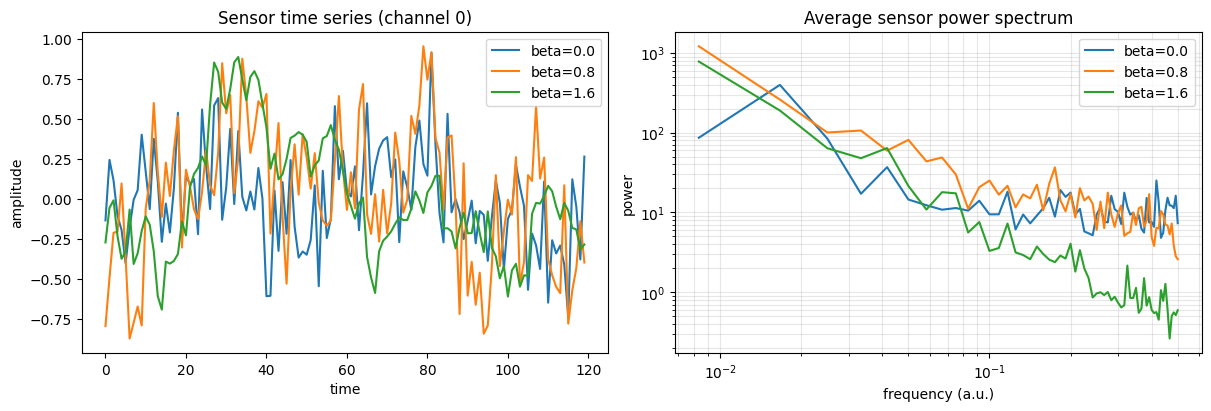

In [17]:
betas = [0.0, 0.8, 1.6]
beta_results = {
    b: generate_one(
        mode="low_rank",
        noise_color_coeff=0.7,
        noise_temporal_beta=b,
        noise_rank_deficiency=2,
        seed=100 + int(10 * b),
    )
    for b in betas
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for b in betas:
    x = beta_results[b]["x"]
    # plot a representative channel
    axes[0].plot(x[0], label=f"beta={b}")

    # channel-averaged power spectrum
    Xf = np.fft.rfft(x, axis=1)
    pxx = np.mean(np.abs(Xf) ** 2, axis=0)
    freqs = np.fft.rfftfreq(x.shape[1], d=1.0)
    valid = freqs > 0
    axes[1].loglog(freqs[valid], pxx[valid], label=f"beta={b}")

axes[0].set_title("Sensor time series (channel 0)")
axes[0].set_xlabel("time")
axes[0].set_ylabel("amplitude")
axes[0].legend()

axes[1].set_title("Average sensor power spectrum")
axes[1].set_xlabel("frequency (a.u.)")
axes[1].set_ylabel("power")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.show()

## 7. Practical next steps

- Use `return_noise_cov=True` and pass `noise_cov_est` into inverse solvers for realistic benchmarks.
- Sweep `noise_rank_deficiency`, `noise_temporal_beta`, and `correlation_mode` as benchmark axes.
- Keep one clean baseline dataset (`mode=None`, `noise_rank_deficiency=0`) for calibration.


## 8. Realistic sample: `dSPM` vs `dSPM-MNE`

This final experiment simulates one sample with realistic noise structure:

- spatially correlated low-rank noise
- temporal color (`1/f^beta`)
- sensor rank deficiency via projector
- estimated noise covariance from baseline noise

Then we run both solvers on the same `mne.EvokedArray` and compare against the ground truth.


In [18]:
import importlib.util as _ilu
from pathlib import Path

import mne
from invert import Solver
from invert.util.util import pos_from_forward


def _find_evaluate_py() -> Path:
    roots = [Path.cwd(), *Path.cwd().parents]
    for root in roots:
        candidates = [
            root / "invert" / "evaluate" / "evaluate.py",
            root / "invert-package" / "invert" / "evaluate" / "evaluate.py",
        ]
        for candidate in candidates:
            if candidate.exists():
                return candidate
    msg = (
        "Could not locate invert/evaluate/evaluate.py from cwd. "
        f"cwd={Path.cwd()}"
    )
    raise FileNotFoundError(msg)


_eval_path = _find_evaluate_py()
_spec = _ilu.spec_from_file_location("invert.evaluate.evaluate", str(_eval_path))
assert _spec is not None and _spec.loader is not None
_eval_mod = _ilu.module_from_spec(_spec)
_spec.loader.exec_module(_eval_mod)
evaluate_all = _eval_mod.evaluate_all
print(f"Loaded evaluate_all from: {_eval_path}")

Loaded evaluate_all from: /Users/lukas/projects/invert/invert-package/invert/evaluate/evaluate.py


In [19]:
realistic_cfg = SimulationConfig(
    batch_size=1,
    batch_repetitions=1,
    n_sources=(2, 4),
    n_orders=(1, 3),
    n_timepoints=120,
    snr_range=(0.0, 0.0),
    simulation_mode="patches",
    correlation_mode="low_rank",
    noise_color_coeff=0.7,
    noise_temporal_beta=1.0,
    noise_rank_deficiency=2,
    apply_sensor_projector=True,
    return_noise_cov=True,
    estimate_noise_cov=True,
    noise_cov_n_baseline=300,
    noise_cov_shrinkage=0.05,
    random_seed=1234,
)

x_batch, y_batch, info_batch = next(SimulationGenerator(fwd, config=realistic_cfg).generate())
x = x_batch[0]
y_true = y_batch[0]
meta = info_batch.iloc[0]

print(f"Target SNR: {meta['snr']:.3f} dB")
print(f"Realized SNR: {meta['snr_realized']:.3f} dB")
print(f"Projector rank: {int(meta['projector_rank'])} / {x.shape[0]}")
print(f"True noise-cov rank: {int(meta['noise_cov_rank_true'])}")
print(f"Estimated noise-cov rank: {int(meta['noise_cov_rank_est'])}")

Target SNR: 0.000 dB
Realized SNR: -0.000 dB
Projector rank: 30 / 32
True noise-cov rank: 30
Estimated noise-cov rank: 32


In [20]:
# Wrap data for solver API
info_eval = info.copy()
evoked = mne.EvokedArray(x, info_eval, tmin=0.0, verbose=0)

# Evaluate on temporally averaged absolute source maps to match benchmark style
y_true_eval = np.abs(y_true).mean(axis=-1, keepdims=True)

adjacency = mne.spatial_src_adjacency(fwd["src"], verbose=0)
pos = pos_from_forward(fwd)

results = []

# Legacy dSPM (does not use noise_cov internals)
solver_dspm = Solver("dSPM")
solver_dspm.make_inverse_operator(fwd, alpha="auto")
stc_dspm = solver_dspm.apply_inverse_operator(evoked)
y_pred_dspm = np.abs(stc_dspm.data).mean(axis=-1, keepdims=True)
metrics_dspm = evaluate_all(y_true_eval, y_pred_dspm, adjacency, adjacency, pos, pos)
results.append(("dSPM", metrics_dspm, stc_dspm.data))

# MNE-style dSPM (uses estimated noise covariance)
solver_dspm_mne = Solver("dspm-mne")
solver_dspm_mne.make_inverse_operator(
    fwd,
    alpha="auto",
    noise_cov=meta["noise_cov_est"],
)
stc_dspm_mne = solver_dspm_mne.apply_inverse_operator(evoked)
y_pred_dspm_mne = np.abs(stc_dspm_mne.data).mean(axis=-1, keepdims=True)
metrics_dspm_mne = evaluate_all(y_true_eval, y_pred_dspm_mne, adjacency, adjacency, pos, pos)
results.append(("dSPM-MNE", metrics_dspm_mne, stc_dspm_mne.data))

def metric_get(metrics, *aliases):
    lowered = {str(k).lower(): v for k, v in metrics.items()}
    for alias in aliases:
        key = alias.lower()
        if key in lowered:
            return float(lowered[key])
    return float('nan')

for name, metrics, _ in results:
    print(f"\n{name}")
    print(f"  MLE: {metric_get(metrics, 'Mean_Localization_Error', 'mean_localization_error'):.4f}")
    print(f"  EMD: {metric_get(metrics, 'EMD', 'emd'):.4f}")
    print(f"  SD:  {metric_get(metrics, 'sd', 'spatial_dispersion'):.4f}")
    print(f"  AP:  {metric_get(metrics, 'average_precision'):.4f}")
    print(f"  Corr:{metric_get(metrics, 'correlation'):.4f}")


dSPM
  MLE: 44.3882
  EMD: 45.1174
  SD:  26.2660
  AP:  0.1758
  Corr:0.0240

dSPM-MNE
  MLE: 35.6469
  EMD: 46.1442
  SD:  61.1952
  AP:  0.1725
  Corr:-0.0158


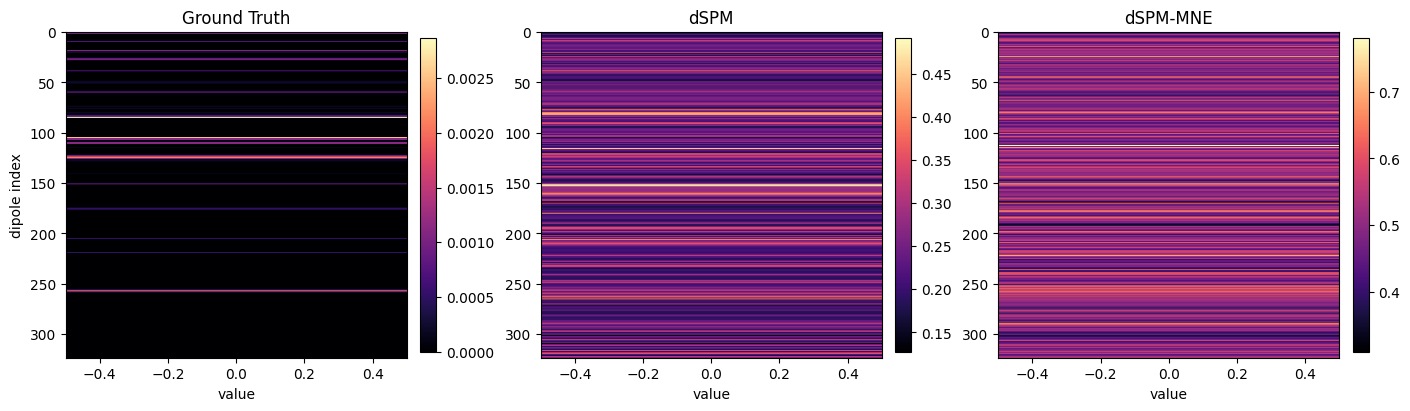

In [21]:
# Visual comparison of ground truth and both predictions (mean abs over time)
truth_map = np.abs(y_true).mean(axis=-1)
dspm_map = np.abs(results[0][2]).mean(axis=-1)
dspm_mne_map = np.abs(results[1][2]).mean(axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

im0 = axes[0].imshow(truth_map[:, None], aspect="auto", cmap="magma")
axes[0].set_title("Ground Truth")
axes[0].set_xlabel("value")
axes[0].set_ylabel("dipole index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(dspm_map[:, None], aspect="auto", cmap="magma")
axes[1].set_title("dSPM")
axes[1].set_xlabel("value")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(dspm_mne_map[:, None], aspect="auto", cmap="magma")
axes[2].set_title("dSPM-MNE")
axes[2].set_xlabel("value")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()